In [ ]:
import src.utils_1 as utils_1
from importlib import reload

reload(utils_1)

<module 'src.utils_1' from 'c:\\Users\\charl\\OneDrive\\Bureau\\A4\\DIA\\NLP_Supervised_Learning\\notebooks\\src\\utils_1.py'>

In [54]:
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

DATA_DIR = Path.cwd() / ".." / "data"
DATA_URL = "https://github.com/Aureleee/NLP_Supervised_Learning/releases/download/v1.0.0/"
FILE_PATTERN = "avis_*_traduit.xlsx"
OUTPUT_DIR = DATA_DIR / "outputs"


In [34]:
for i in range(1, 36):
    file_name = f"avis_{i}_traduit.xlsx"
    file_dir = DATA_DIR / file_name
    utils_1.ensure_data(DATA_DIR, file_dir, f"{DATA_URL}{file_name}")

Data not found at c:\Users\charl\OneDrive\Bureau\A4\DIA\NLP_Supervised_Learning\notebooks\..\data\avis_1_traduit.xlsx. Downloading from GitHub...
Download successful!
Data not found at c:\Users\charl\OneDrive\Bureau\A4\DIA\NLP_Supervised_Learning\notebooks\..\data\avis_2_traduit.xlsx. Downloading from GitHub...
Download successful!
Data not found at c:\Users\charl\OneDrive\Bureau\A4\DIA\NLP_Supervised_Learning\notebooks\..\data\avis_3_traduit.xlsx. Downloading from GitHub...
Download successful!
Data not found at c:\Users\charl\OneDrive\Bureau\A4\DIA\NLP_Supervised_Learning\notebooks\..\data\avis_4_traduit.xlsx. Downloading from GitHub...
Download successful!
Data not found at c:\Users\charl\OneDrive\Bureau\A4\DIA\NLP_Supervised_Learning\notebooks\..\data\avis_5_traduit.xlsx. Downloading from GitHub...
Download successful!
Data not found at c:\Users\charl\OneDrive\Bureau\A4\DIA\NLP_Supervised_Learning\notebooks\..\data\avis_6_traduit.xlsx. Downloading from GitHub...
Download successful

In [37]:
files = utils_1.list_excel_files(DATA_DIR, pattern=FILE_PATTERN)
if not files:
        raise FileNotFoundError(
            f"No files found in {DATA_DIR} matching pattern {FILE_PATTERN!r}."
        )

In [39]:
df_raw = utils_1.concat_review_files(files)

df_raw.head()

,note,auteur,avis,assureur,produit,type,date_publication,date_exp,avis_en,avis_cor,avis_cor_en,source_file,source_id
0,5.0,brahim--k-131532,"Meilleurs assurances, prix, solutions, écoute,...",Direct Assurance,auto,train,06/09/2021,01/09/2021,"Best insurance, price, solutions, listening, s...",NaN,NaN,avis_1_traduit.xlsx,1
1,4.0,bernard-g-112497,"je suis globalement satisfait , sauf que vous ...",Direct Assurance,auto,train,03/05/2021,01/05/2021,"I am generally satisfied, except that you have...",NaN,NaN,avis_1_traduit.xlsx,1
2,5.0,virginie-t-107352,Prix tres abordable plusieurs options s'offren...,Direct Assurance,auto,train,21/03/2021,01/03/2021,Very affordable price Several options are avai...,NaN,NaN,avis_1_traduit.xlsx,1
3,4.0,boulain-f-116580,"je satisfait du service, une réponse très rapi...",L'olivier Assurance,auto,train,10/06/2021,01/06/2021,"I satisfy the service, a very fast response fr...",NaN,NaN,avis_1_traduit.xlsx,1
4,1.0,ouaille31-51798,"Client depuis plus de 25 ans, très déçu de cet...",Matmut,auto,train,29/01/2017,01/01/2017,"Customer for more than 25 years, very disappoi...",NaN,NaN,avis_1_traduit.xlsx,1


In [41]:
df_prepared = utils_1.minimal_prepare(df_raw)

df_prepared.head()

,row_uid,note,auteur,avis,assureur,produit,type,date_publication,date_exp,avis_en,avis_cor,avis_cor_en,source_file,source_id
0,1,5.0,brahim--k-131532,"Meilleurs assurances, prix, solutions, écoute,...",Direct Assurance,auto,train,06/09/2021,01/09/2021,"Best insurance, price, solutions, listening, s...",NaN,NaN,avis_1_traduit.xlsx,1
1,2,4.0,bernard-g-112497,"je suis globalement satisfait , sauf que vous ...",Direct Assurance,auto,train,03/05/2021,01/05/2021,"I am generally satisfied, except that you have...",NaN,NaN,avis_1_traduit.xlsx,1
2,3,5.0,virginie-t-107352,Prix tres abordable plusieurs options s'offren...,Direct Assurance,auto,train,21/03/2021,01/03/2021,Very affordable price Several options are avai...,NaN,NaN,avis_1_traduit.xlsx,1
3,4,4.0,boulain-f-116580,"je satisfait du service, une réponse très rapi...",L'olivier Assurance,auto,train,10/06/2021,01/06/2021,"I satisfy the service, a very fast response fr...",NaN,NaN,avis_1_traduit.xlsx,1
4,5,1.0,ouaille31-51798,"Client depuis plus de 25 ans, très déçu de cet...",Matmut,auto,train,29/01/2017,01/01/2017,"Customer for more than 25 years, very disappoi...",NaN,NaN,avis_1_traduit.xlsx,1


In [44]:
utils_1.export_dataframe(df_raw, OUTPUT_DIR / "reviews_concat_raw.csv")
utils_1.export_dataframe(df_prepared, OUTPUT_DIR / "reviews_concat_prepared.csv")

print(f"Files detected: {len(files)}")
print(f"Rows in raw concatenated dataframe: {len(df_raw)}")
print(f"Columns: {list(df_raw.columns)}")
print(f"Saved raw file to: {OUTPUT_DIR / 'reviews_concat_raw.csv'}")
print(f"Saved prepared file to: {OUTPUT_DIR / 'reviews_concat_prepared.csv'}")

Files detected: 35
Rows in raw concatenated dataframe: 34435
Columns: ['note', 'auteur', 'avis', 'assureur', 'produit', 'type', 'date_publication', 'date_exp', 'avis_en', 'avis_cor', 'avis_cor_en', 'source_file', 'source_id']
Saved raw file to: c:\Users\charl\OneDrive\Bureau\A4\DIA\NLP_Supervised_Learning\notebooks\..\data\outputs\reviews_concat_raw.csv
Saved prepared file to: c:\Users\charl\OneDrive\Bureau\A4\DIA\NLP_Supervised_Learning\notebooks\..\data\outputs\reviews_concat_prepared.csv


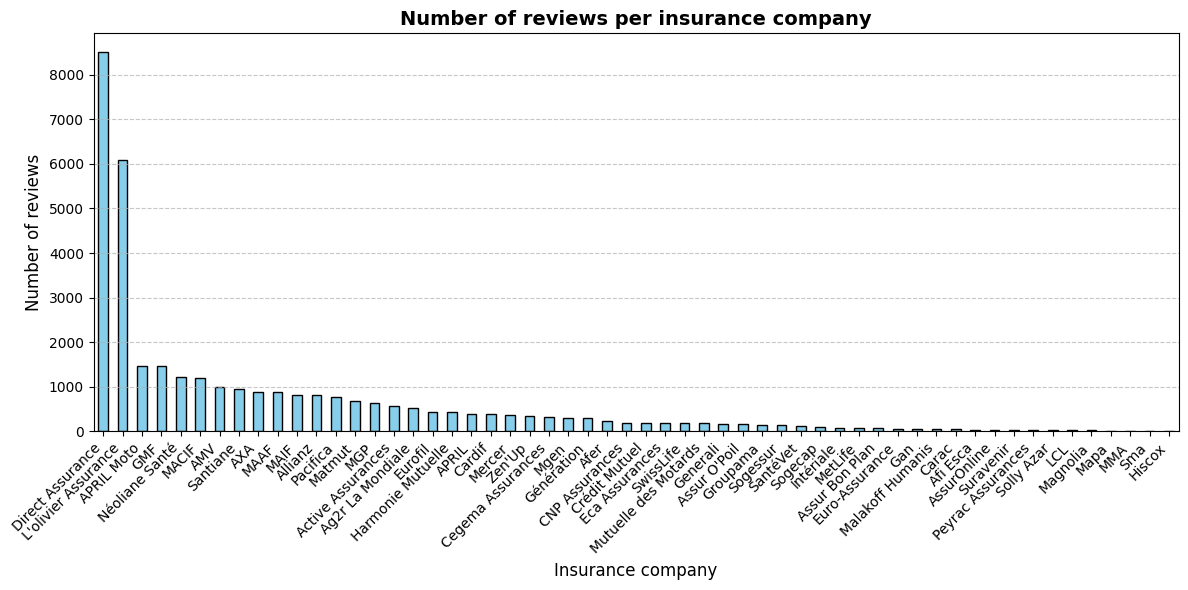

In [50]:
nb_reviews = df_prepared['assureur'].value_counts().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
nb_reviews.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Number of reviews per insurance company", fontsize=14, fontweight='bold')
plt.xlabel("Insurance company", fontsize=12)
plt.ylabel("Number of reviews", fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotate names so they don't overlap
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout() # Ensures labels are not truncated
plt.show()

Judging from the discrepency in number of reviews, we will probably have to include a minimum number of reviews, so the model isn't skewed

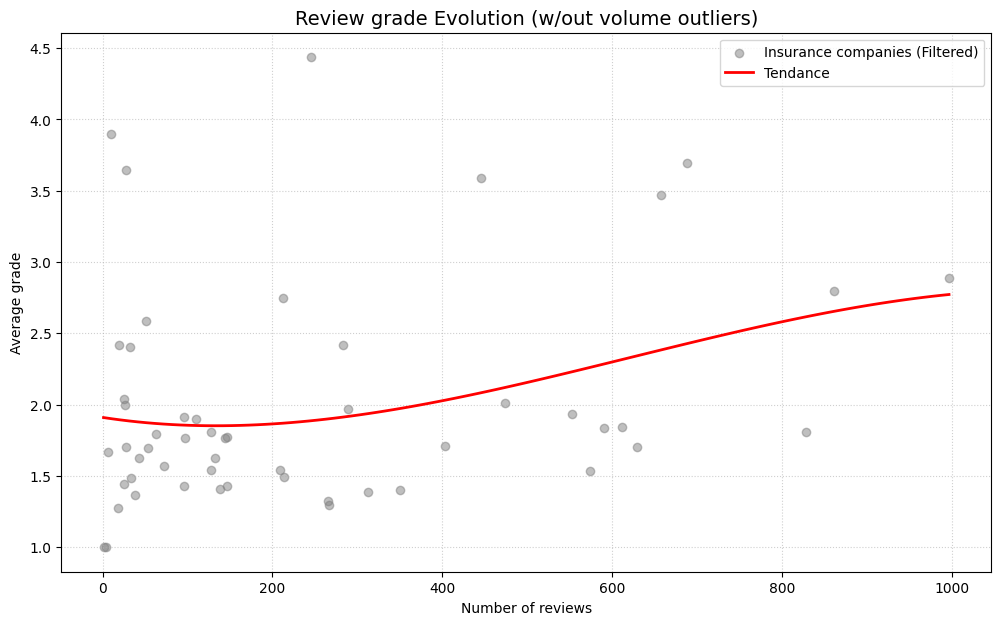

In [65]:
stats = df_prepared.groupby('assureur')['note'].agg(['count', 'mean']).reset_index()
q_high = stats['count'].quantile(0.95)
stats_filtered = stats[stats['count'] < q_high].copy()
stats_filtered = stats_filtered.sort_values(by='count')

x = stats_filtered['count']
y = stats_filtered['mean']

plt.figure(figsize=(12, 7))
plt.scatter(x, y, alpha=0.5, color='gray', label='Insurance companies (Filtered)')
z = np.polyfit(x, y, 3)
p = np.poly1d(z)
x_range = np.linspace(x.min(), x.max(), 100)
plt.plot(x_range, p(x_range), color="red", linewidth=2, label="Tendance")
plt.title("Review grade Evolution (w/out volume outliers)", fontsize=14)
plt.xlabel("Number of reviews")
plt.ylabel("Average grade")
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()